# ИИ-помощник директора школы

**Вариант 1:** RAG-система для анализа документов  
**Выполнил:** Метельский Тарас Леонидович

Цель — разработать FastAPI-сервис, который индексирует школьную нормативную и методическую базу, отвечает только по найденному контексту и возвращает документ, страницу и чанк каждого источника.

## 1. Датасет и обоснование выбора

Использованы два официальных тома «Настольной книги директора школы»: «Знание» и «Здоровье». Корпус содержит русскоязычные нормативные выдержки и методические рекомендации, объединяет разные управленческие темы и позволяет проверять найденный ответ по странице. Это практичнее случайных новостей: результат можно использовать как прототип помощника руководителя школы.

In [1]:
import json
import os
import tempfile
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from fastapi.testclient import TestClient

os.environ["EMBEDDING_PROVIDER"] = "hashing"
from app.config import get_settings
from app.llm import SYSTEM_PROMPT
from app.main import create_app
from app.service import KnowledgeBaseService
from embedding_benchmark import MODELS, QUERIES
os.environ["EMBEDDING_PROVIDER"] = "sentence-transformers"
os.environ["EMBEDDING_MODEL"] = "intfloat/multilingual-e5-small"

PROJECT = Path.cwd()
SEED_DIR = PROJECT / "data" / "seed"
seed_files = sorted(SEED_DIR.glob("*.pdf"))
display(pd.DataFrame({
    "Документ": [path.name for path in seed_files],
    "Размер, МБ": [round(path.stat().st_size / 1024**2, 2) for path in seed_files],
}))

/root/.local/lib/python3.12/site-packages/fastapi/testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient as TestClient  # noqa


,Документ,"Размер, МБ"
0,01_Kniga_direktora_Znanie.pdf,7.44
1,02_Kniga_direktora_Zdorove.pdf,8.00


## 2. Чанкинг

PDF обрабатывается постранично. Абзацы объединяются до **1000 символов**, overlap — **180 символов**. Такой размер обычно вмещает законченный пункт или несколько связанных предложений, но остаётся достаточно узким для точного поиска. Перекрытие сохраняет смысл на границах фрагментов. В метаданные записываются имя файла, дата загрузки, `document_id`, страница и номер чанка.

In [2]:
from app.document_processing import extract_pages, split_pages

chunk_rows = []
for path in seed_files:
    pages = extract_pages(path)
    chunks = split_pages(pages, chunk_size=1000, overlap=180)
    chunk_rows.append({"Документ": path.name, "Страниц": len(pages), "Чанков": len(chunks)})
chunk_df = pd.DataFrame(chunk_rows)
display(chunk_df)
print("Всего чанков:", int(chunk_df["Чанков"].sum()))

Всего чанков: 547


,Документ,Страниц,Чанков
0,01_Kniga_direktora_Znanie.pdf,67,303
1,02_Kniga_direktora_Zdorove.pdf,66,244


## 3. Сравнение трёх моделей эмбеддингов

Все модели проверены на одних и тех же 547 чанках и 10 вручную размеченных запросах. Релевантность задана парой «документ + допустимая страница».

- `Hit@3` — доля вопросов, для которых релевантный чанк найден в первой тройке;
- `MRR` — среднее обратное значение ранга первого релевантного чанка;
- дополнительно измерены время кодирования корпуса и задержка запроса.

Полный воспроизводимый эксперимент находится в `embedding_benchmark.py`; результаты сохранены в JSON и CSV.

,Модель,Размерность,Hit@3,MRR,"Кодирование корпуса, с",Чанков/с,"Запрос, мс"
0,sentence-transformers/all-MiniLM-L6-v2,384,0.0,0.00,10.313,53.04,11.54
1,sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2,384,0.7,0.65,9.784,55.91,22.22
2,intfloat/multilingual-e5-small,384,0.9,0.85,29.813,18.35,18.02


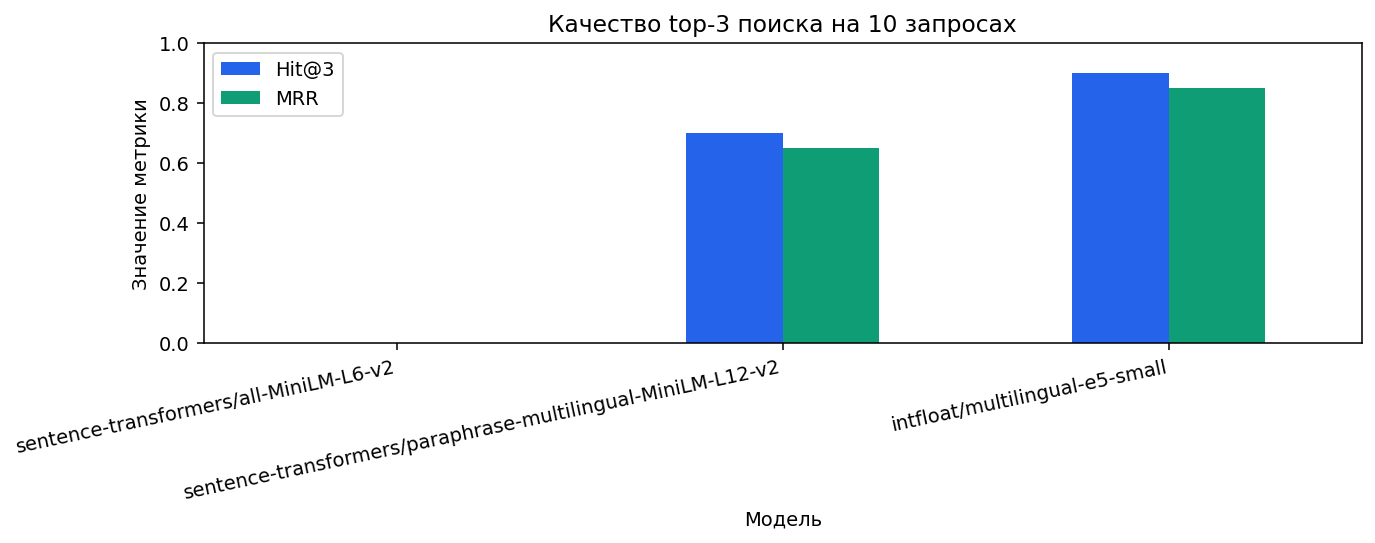

In [3]:
benchmark = json.loads((PROJECT / "embedding_benchmark_results.json").read_text(encoding="utf-8"))
benchmark_df = pd.DataFrame(benchmark["summary"])[[
    "model", "dimensions", "hit_at_3", "mrr", "corpus_encode_s", "chunks_per_s", "mean_query_ms"
]].rename(columns={
    "model": "Модель", "dimensions": "Размерность", "hit_at_3": "Hit@3",
    "mrr": "MRR", "corpus_encode_s": "Кодирование корпуса, с",
    "chunks_per_s": "Чанков/с", "mean_query_ms": "Запрос, мс",
})
display(benchmark_df)
benchmark_df.set_index("Модель")[["Hit@3", "MRR"]].plot(
    kind="bar", figsize=(10, 4), color=["#2563eb", "#0f9d76"]
)
plt.ylim(0, 1)
plt.ylabel("Значение метрики")
plt.title("Качество top-3 поиска на 10 запросах")
plt.xticks(rotation=12, ha="right")
plt.tight_layout()
plt.show()

In [4]:
selected = benchmark["selected_model"]
selected_details = [row for row in benchmark["details"] if row["model"] == selected]
display(pd.DataFrame([{
    "Вопрос": row["question"],
    "Ожидаемые страницы": ", ".join(map(str, row["expected_pages"])),
    "Ранг": row["rank"] if row["rank"] is not None else "не найдено",
    "Top-1": f"{row['top_3'][0]['filename']}, стр. {row['top_3'][0]['page']}",
} for row in selected_details]))
print("Выбранная модель:", selected)
print("Правило выбора:", benchmark["selection_rule"])

Выбранная модель: intfloat/multilingual-e5-small
Правило выбора: max Hit@3, затем max MRR, затем min mean_query_ms


,Вопрос,Ожидаемые страницы,Ранг,Top-1
0,Что включает план внеурочной деятельности школы?,"25, 49",1,"01_Kniga_direktora_Znanie.pdf, стр. 49"
1,Как проводится школьный этап Всероссийской олимпиады школьников?,"53, 54",1,"01_Kniga_direktora_Znanie.pdf, стр. 54"
2,Что такое индивидуальный учебный план обучающегося?,"18, 24",1,"01_Kniga_direktora_Znanie.pdf, стр. 18"
3,Как составлять календарный учебный график по триместрам?,"25, 26",1,"01_Kniga_direktora_Znanie.pdf, стр. 25"
4,Из каких разделов состоит федеральная образовательная программа?,"10, 11, 12",2,"01_Kniga_direktora_Znanie.pdf, стр. 18"
5,Какие рекомендации даны по составлению школьного расписания?,"39, 40",1,"02_Kniga_direktora_Zdorove.pdf, стр. 39"
6,Как организовать качественное горячее питание учеников начальной школы?,"35, 36, 37",1,"02_Kniga_direktora_Zdorove.pdf, стр. 36"
7,Как школе выстроить профилактику травматизма обучающихся?,"47, 48",1,"02_Kniga_direktora_Zdorove.pdf, стр. 47"
8,Какие материалы предназначены для обучения работников первой помощи?,50,1,"02_Kniga_direktora_Zdorove.pdf, стр. 50"
9,Что делать при наружном кровотечении у пострадавшего?,"51, 52, 53",не найдено,"02_Kniga_direktora_Zdorove.pdf, стр. 63"


## 4. Выбор модели

`all-MiniLM-L6-v2` ориентирована прежде всего на английский язык и на данном русском корпусе показала `Hit@3 = 0.00`. Многоязычная MiniLM достигла `0.70`, а `multilingual-e5-small` — `0.90` при `MRR = 0.85`. Поэтому в RAG-системе используется **`intfloat/multilingual-e5-small`**. Для E5 запросы получают префикс `query:`, документы — `passage:`.

Метрики относятся только к небольшой размеченной выборке и не доказывают юридическую корректность ответов.

## 5. Индексация в ChromaDB выбранной моделью

ChromaDB хранит E5-векторы и метаданные. При загрузке рассчитывается SHA-256, поэтому дубликат отклоняется. Удаление документа очищает реестр, файл и все его векторы.

In [5]:
work_dir = Path(tempfile.mkdtemp(prefix="school_director_notebook_"))
settings = get_settings(work_dir / "data")
service = KnowledgeBaseService(settings)

indexed = []
for path in seed_files:
    started = time.perf_counter()
    item = service.upload_path(path)
    indexed.append({
        "Документ": item["filename"], "Страниц": item["pages"],
        "Чанков": item["chunks"], "Дата загрузки": item["uploaded_at"],
        "Время, с": round(time.perf_counter() - started, 2),
    })
display(pd.DataFrame(indexed))
print("Векторов в ChromaDB:", service.collection.count())
print("Embedding model:", service.embedding.name)

Векторов в ChromaDB: 547
Embedding model: intfloat/multilingual-e5-small


Loading weights: 100%|##########| 199/199 [00:00<00:00, 3631.67it/s]


,Документ,Страниц,Чанков,Дата загрузки,"Время, с"
0,01_Kniga_direktora_Znanie.pdf,67,303,2026-08-31T11:51:50.639724+00:00,18.66
1,02_Kniga_direktora_Zdorove.pdf,66,244,2026-08-31T11:52:09.296382+00:00,13.07


## 6. Поиск релевантных чанков

Вопрос кодируется выбранной E5-моделью. ChromaDB выполняет cosine search, после чего результаты очищаются от дублей и фильтруются по релевантности.

,Документ,Страница,Чанк,Релевантность,Фрагмент
0,02_Kniga_direktora_Zdorove.pdf,37,6,0.8967,одические рекомендации по публикации меню \nна сайтах образовательных организаций\nЦель рекомендаций — информирование родителей о питании обуча-\nющихся в образовательной организации.…
1,02_Kniga_direktora_Zdorove.pdf,34,1,0.8870,"Документы \nи методические \nрекомендации \nпо организации питания \nобучающихся\n3.1. Рекомендации \nпо санитарной безопасности \nдля организаций воспитания \nи обучения, отдыха \nи оздоро…"
2,02_Kniga_direktora_Zdorove.pdf,37,5,0.8862,еством потребляемых блюд по \nрезультатам выборочного опроса детей с согласия их родителей или иных \nзаконных представителей;\n■ \nинформирование родителей и детей о здоровом питании.…
3,02_Kniga_direktora_Zdorove.pdf,36,6,0.8851,"анение серьёзных разногласий по по-\nводу оценки качества питания со стороны обучающихся, родителей, адми-\nнистрации, представителей органов здравоохранения и проверяющих ор-\nганов.…"
4,02_Kniga_direktora_Zdorove.pdf,36,5,0.8841,щихся начальной школы \nна уровне образовательной организации и на уровне пищеблока. Регулярное горячее питание \nимеет значимый здоровьеформирующий и здоровьесберегающий потенциалы.…


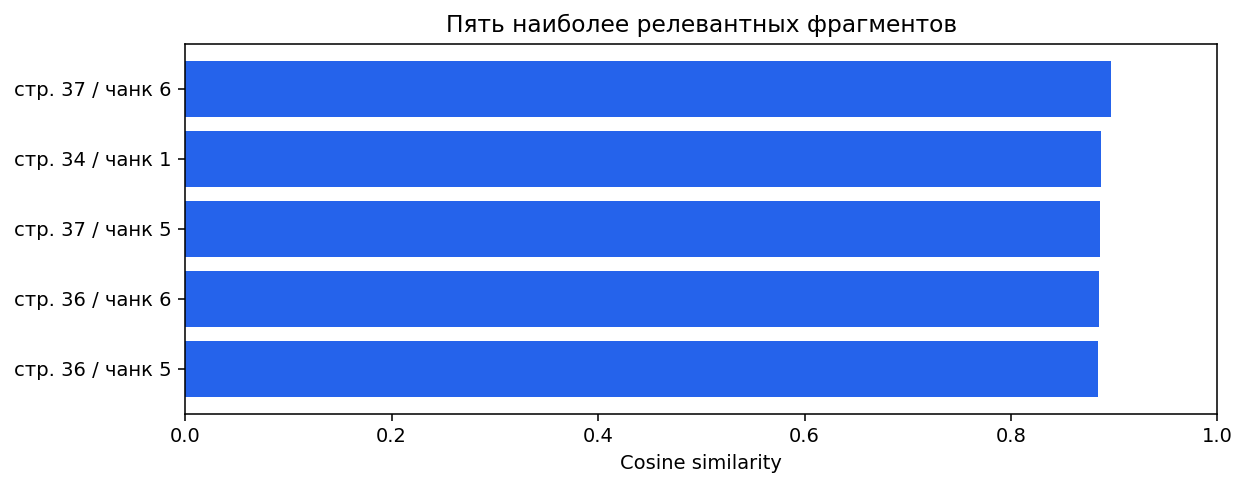

In [6]:
question = "Какие рекомендации даны по организации питания обучающихся?"
results = service.search(question, top_k=5)
display(pd.DataFrame([{
    "Документ": item["filename"], "Страница": item["page"], "Чанк": item["chunk"],
    "Релевантность": item["score"], "Фрагмент": item["text"][:180] + "…",
} for item in results]))

plt.figure(figsize=(9, 3.6))
plt.barh([f"стр. {r['page']} / чанк {r['chunk']}" for r in results][::-1],
         [r["score"] for r in results][::-1], color="#2563eb")
plt.xlabel("Cosine similarity")
plt.title("Пять наиболее релевантных фрагментов")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

## 7. Генерация ответа и источники

LLM подключается через OpenAI-совместимый API или Ollama. Промпт запрещает использовать сведения вне контекста, придумывать статьи и даты, требует различать нормы и рекомендации и честно сообщать о недостатке данных. Без API-ключа работает безопасный extractive-режим.

In [7]:
print(SYSTEM_PROMPT)

Ты — информационно-справочный помощник руководителя российской образовательной организации.
Отвечай только на основании предоставленного контекста из загруженной нормативной и методической базы.

Правила:
1. Не добавляй сведения, которых нет в контексте.
2. Не придумывай названия документов, даты, номера статей и обязанности.
3. Если данных недостаточно, прямо сообщи об этом.
4. Отделяй обязательные требования от методических рекомендаций.
5. При противоречии источников укажи на него и не выбирай норму самостоятельно.
6. Ответ должен быть кратким, понятным и проверяемым.
7. Ссылайся на источники в формате [Источник N].



In [8]:
answer = service.ask(question, top_k=4)
print("Статус:", answer["answer_status"])
print("Провайдер:", answer["llm_provider"])
print("Ответ:", answer["answer"], sep="\n")
display(pd.DataFrame([{
    "Источник": source["filename"], "Страница": source["page"],
    "Чанк": source["chunk"], "Score": source["score"],
} for source in answer["sources"]]))

Статус: grounded
Провайдер: extractive-fallback
Ответ:
По загруженной базе: одические рекомендации по публикации меню  на сайтах образовательных организаций Цель рекомендаций — информирование родителей о питании обуча- ющихся в образовательной организации. Это даёт возможность родителям  осуществлять контроль за эффективностью организации питания с соблю- дением установленных санитарных требований к меню и рационов пита- ния. ВАЖНО Цель контроля — обе- спечение качественного  и здорового питания об- учающихся начального  уровня  образования,  пропаганды основ здо- рового питания при вза- имодействии с обще школьным родительским  комитетом и обществен- ными организациями. [Источник 1]


,Источник,Страница,Чанк,Score
0,02_Kniga_direktora_Zdorove.pdf,37,6,0.8967
1,02_Kniga_direktora_Zdorove.pdf,34,1,0.8870
2,02_Kniga_direktora_Zdorove.pdf,37,5,0.8862
3,02_Kniga_direktora_Zdorove.pdf,36,6,0.8851


## 8. FastAPI и пользовательский интерфейс

Реализованы `GET /`, `POST /upload`, `POST /ask`, `GET /documents`, `DELETE /documents/{id}`. Pydantic проверяет вопрос и `top_k`; предусмотрены ответы 400, 404, 409, 413, 422, 500 и 503. HTML-страница содержит загрузку, список документов, вопрос, ответ и источники.

Endpoint-цикл ниже проверяется на быстром deterministic backend; E5 уже отдельно проверена и использована при индексации основного корпуса выше.

In [9]:
os.environ["EMBEDDING_PROVIDER"] = "hashing"
client = TestClient(create_app(work_dir / "api_data"))
sample_text = (
    "Охрана здоровья обучающихся включает организацию питания, обеспечение безопасности "
    "и определение оптимальной учебной нагрузки. Руководитель образовательной организации "
    "организует контроль условий обучения."
)
checks = []
r = client.get("/"); checks.append(("GET /", r.status_code, "HTML"))
r = client.post("/upload", files={"file": ("demo_rules.txt", sample_text.encode(), "text/plain")})
document_id = r.json()["document_id"]; checks.append(("POST /upload", r.status_code, "indexed"))
r = client.post("/ask", json={"question": "Кто организует контроль условий обучения?", "top_k": 3})
checks.append(("POST /ask", r.status_code, r.json()["answer_status"]))
r = client.get("/documents"); checks.append(("GET /documents", r.status_code, f"{len(r.json())} документ"))
r = client.delete(f"/documents/{document_id}"); checks.append(("DELETE /documents/{id}", r.status_code, r.json()["status"]))
display(pd.DataFrame(checks, columns=["Эндпоинт", "HTTP", "Результат"]))
os.environ["EMBEDDING_PROVIDER"] = "sentence-transformers"

,Эндпоинт,HTTP,Результат
0,GET /,200,HTML
1,POST /upload,201,indexed
2,POST /ask,200,grounded
3,GET /documents,200,1 документ
4,DELETE /documents/{id},200,deleted


## 9. Итог

Создан работающий RAG-сервис по школьной документальной базе. Три модели эмбеддингов сравнены на одинаковом корпусе; выбрана `multilingual-e5-small`. Документы индексируются в ChromaDB, LLM отвечает по найденным чанкам, а API возвращает проверяемые источники. Все обязательные endpoint-сценарии реализованы.

Ограничения: десять запросов — небольшая оценочная выборка; методическая книга не заменяет актуальную редакцию нормативного акта; сканированные PDF требуют OCR; ответы для практического решения должны проверяться ответственным специалистом.